In [1]:
from PINN_XWave_DDP import *

Given parameters: omega_ce = 2.0, omega_pe = 1.0
R-cutoff frequency: 2.414213562373095
L-cutoff frequency: 0.41421356237309515
Upper Hybrid resonance frequency: 2.23606797749979


/home/aleotz/Plasma_PINNS/PINN_XWave_DDP.py:132: RuntimeWarning: invalid value encountered in sqrt
  k = np.sqrt(omega**2 - (omega**2 - 1) / (omega**2 - 1 - omega_ce**2))


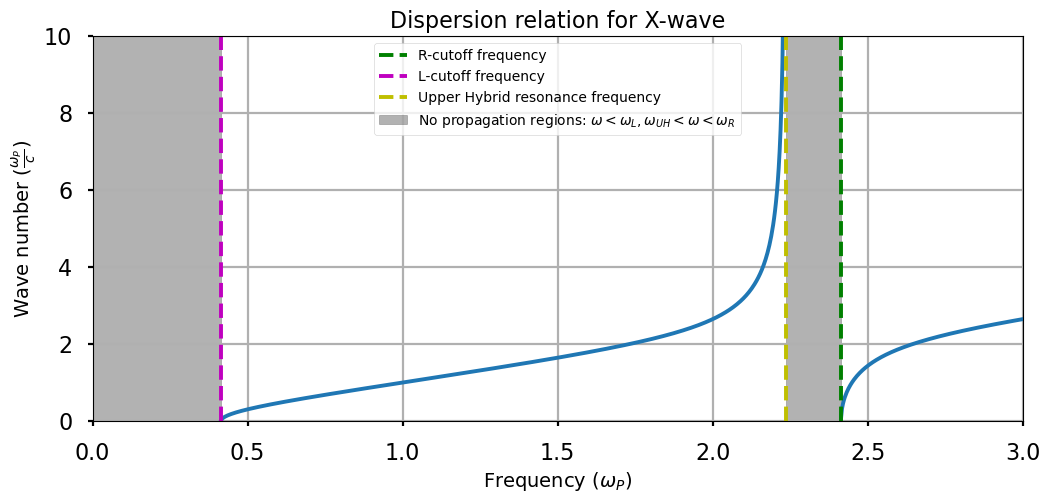

In [2]:
def calc_criticical_freq(omega_ce, omega_pe=1.):
    
    #Cutoff occurs when the index of refraction goes to zero => k->infinity (refelcted)
    #Resonance occurs when the index of refraction goes to infinity => k->0 (absorbed)
    
    #R-cutoff frequency
    omega_r = 1/2*(omega_ce + np.sqrt(omega_ce**2 + 4*omega_pe**2))
    
    #L_cutoff
    omega_l = 1/2*(-omega_ce + np.sqrt(omega_ce**2 + 4*omega_pe**2))
    
    #UH resonance: At this frequency, the wave is absorbed by the plasma
    omega_uh = np.sqrt(omega_ce**2 + omega_pe**2)
    
    print(f"Given parameters: omega_ce = {omega_ce}, omega_pe = {omega_pe}")
    print(f"R-cutoff frequency: {omega_r}")
    print(f"L-cutoff frequency: {omega_l}")
    print(f"Upper Hybrid resonance frequency: {omega_uh}")
    
    return omega_r, omega_l, omega_uh


def plot_phase_versus_frequency(omega_ce, omega_pe=1.):
    omega = np.linspace(0., 3, 1000)
    k = dispersion(omega, omega_ce)
    
    plt.figure(figsize=(12,5))
    plt.plot(omega, k)
    plt.ylim(0,10)
    plt.xlim(0,3)
    plt.xlabel(r"Frequency ($\omega_P$)", fontsize=14)
    plt.ylabel(r"Wave number ($\frac{\omega_P}{c}$)", fontsize=14)
    plt.title(r"Dispersion relation for X-wave", fontsize=16)
    plt.grid()
    # plt.axvline(x=omega_ce, color='r', linestyle='--', label='Cyclotron frequency')
    omega_r, omega_l, omega_uh = calc_criticical_freq(omega_ce, omega_pe)
    plt.axvline(x=omega_r, color='g', linestyle='--', label='R-cutoff frequency')
    plt.axvline(x=omega_l, color='m', linestyle='--', label='L-cutoff frequency')
    plt.axvline(x=omega_uh, color='y', linestyle='--', label='Upper Hybrid resonance frequency')
    
    #Shaded regions of no propagation
    plt.fill([0, omega_l, omega_l, 0], [0, 0, 10, 10], color='black', alpha=0.3, label = r'No propagation regions: $\omega < \omega_L, \omega_{UH} < \omega < \omega_{R}$')
    plt.fill([omega_uh, omega_r, omega_r, omega_uh], [0, 0, 10, 10], color='black', alpha=0.3)
    
    plt.legend(prop = {'size': 10})
    plt.show()
    
    return None
    
plot_phase_versus_frequency(omega_ce=2., omega_pe=1.)    
    

In [3]:
#Global variables physics constants
omega_ce = 2. #B0 is equal to omega_ce in normalized units
B0 = omega_ce  #Background magnetic field in z direction
omega = 1.5
phi_amp = 1.


k = dispersion(omega, omega_ce)
print(f"k = {k:.3f}")

omega_list = [omega]
phi_amp_list = [phi_amp]  # Amplitude of the electric field
delta_list = [0.0]  # Phase factor for the wave solution
B0_list = [B0]

lamda = 2 * np.pi / k  # Wavelength
T = (2 * np.pi) / omega  # Period of the wave
xmin, xmax = 0, 3*lamda
tmin, tmax = 0, 3*T

L = xmax - xmin         # Length of the domain
tau = tmax - tmin       # Time duration of the wave
Nt = 2000               # Number of time points
Nx = 2000               # Number of spatial points
Nt_coll = 200           #number of collocation points in time
Nx_coll = 200           #number of collocation points in space
dt = T/float(Nt)
dx = L/float(Nx)

t_arr = np.linspace(tmin, tmax, Nt)
x_arr = np.linspace(xmin, xmax, Nx)

print(f"k = {k:.4e}")
print(f"L = {L:.3e} [c / omega_pe]")
print(f"T = {T:.3e} [1 / omega_pe]")
print(f"dx = {dx:.3e} [c / omega_pe]")
print(f"dt = {dt:.3e} [1 / omega_pe]")

X_arr, T_arr, phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, B0_flat = generate_data(xmin = xmin, xmax = xmax, tmin = tmin, tmax = tmax, nx = Nx, nt = Nt,
                                                                                                omega_ce = omega_ce, omega_list = omega_list, phi_amp_list=phi_amp_list,
                                                                                                delta_list=delta_list)

#use a percentage of the collocation as sparse measurements
x_sparse, t_sparse, phi_sparse, Bdot_sparse = sparse_measurements(X_arr, T_arr, phi_flat, Bdot_flat, num_samples=int(200))

x_coll, t_coll, dx, dt = collocation_points(xmin, xmax, tmin, tmax, Nx_coll, Nt_coll, L, tau)
if len(x_sparse)==len(x_coll):
    print(f"Number of sparse measurements: {len(x_sparse)} (Full Knowledge)")
else:
    print(f"Number of sparse measurements: {len(x_sparse)}")
print(f"Number of collocation points: {len(x_coll)}")
print(f"Number of grid points: {len(X_arr)}")

k = 1.645
k = 1.6446e+00
L = 1.146e+01 [c / omega_pe]
T = 4.189e+00 [1 / omega_pe]
dx = 5.731e-03 [c / omega_pe]
dt = 2.094e-03 [1 / omega_pe]
Number of sparse measurements: 200
Number of collocation points: 40000
Number of grid points: 4000000


In [4]:
#Plot GTs
def plot_analytical(quantities, sparse, titles, extent, show_sparse=True):
    """Plot the analytical solution."""
    
    
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
    colors = ['PiYG', 'PRGn', 'BrBG',
              'PuOr', 'RdGy', 'RdBu',
              'RdYlBu', 'RdYlGn', 'bwr',
              'seismic', 'berlin', 'vanimo']
    x_sparse = sparse[0]
    t_sparse = sparse[1]
    phi_sparse = sparse[2]
    bdot_sparse = sparse[3]
    
                      
    for ax, quantity, title, color in zip(axes.flatten(), quantities, titles, colors):
        im = ax.imshow(quantity, aspect='auto', extent=extent, origin='lower', cmap=color)
        ax.set_title(title, fontsize = 25)
        ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
        ax.set_ylabel('$t [\\omega_{{pe}}^{{-1}}]$')
        fig.colorbar(im, ax=ax)
        print(title, 'mean: ', np.mean(quantity), ' std: ', np.std(quantity))
        
        
        if show_sparse:
            if f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$' in title:
                ax.scatter(x_sparse, t_sparse, c='black', s=20, label=f'{len(sparse[0])} φ Measurements', alpha=1.)
                ax.legend()
            if f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$' in title:
                ax.scatter(x_sparse, t_sparse, c='black', s=20, label=f'{len(sparse[0])} Bdot Measurements', alpha=1.)
                ax.legend()
            
            
    
    plt.tight_layout()
    plt.show()
    plt.suptitle("Ground Truth")

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\d'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_102478/3836419109.py:20: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
/tmp/ipykernel_102478/3836419109.py:27: SyntaxWarning: invalid escape sequence '\p'
  if f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$' in title:
/tmp/ipykernel_102478/3836419109.py:30: SyntaxWarning: invalid escape sequence '\d'
  if f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$' in title:


-------Plotting Ground Truth Values-------------
$\phi [\frac{m_{e}c^2}{e}]$ mean:  2.5000000000251885e-07  std:  0.7071068695748455
$\dot{B} [\frac{e}{m_{e}c}]$ mean:  -3.1477043194172437e-18  std:  0.6629125244983074
$A_x [\frac{m_{e}c}{e}]$ mean:  2.2802587203731762e-07  std:  0.6449546422394109
$A_y [\frac{m_{e}c}{e}]$ mean:  -1.3073986337985843e-18  std:  0.26873103375033786
$v_x [c]$ mean:  -1.0364812365479458e-07  std:  0.29316120101791393
$v_y [c]$ mean:  7.336353746723035e-19  std:  0.12215046988651729
$N_e [n_0]$ mean:  -1.1363636363633667e-07  std:  0.32141221344311155


<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_102478/103060911.py:7: SyntaxWarning: invalid escape sequence '\p'
  titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$',
/tmp/ipykernel_102478/103060911.py:8: SyntaxWarning: invalid escape sequence '\d'
  f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',


$B_0 [\omega_p \frac{mc}{e}]$ mean:  2.0  std:  0.0


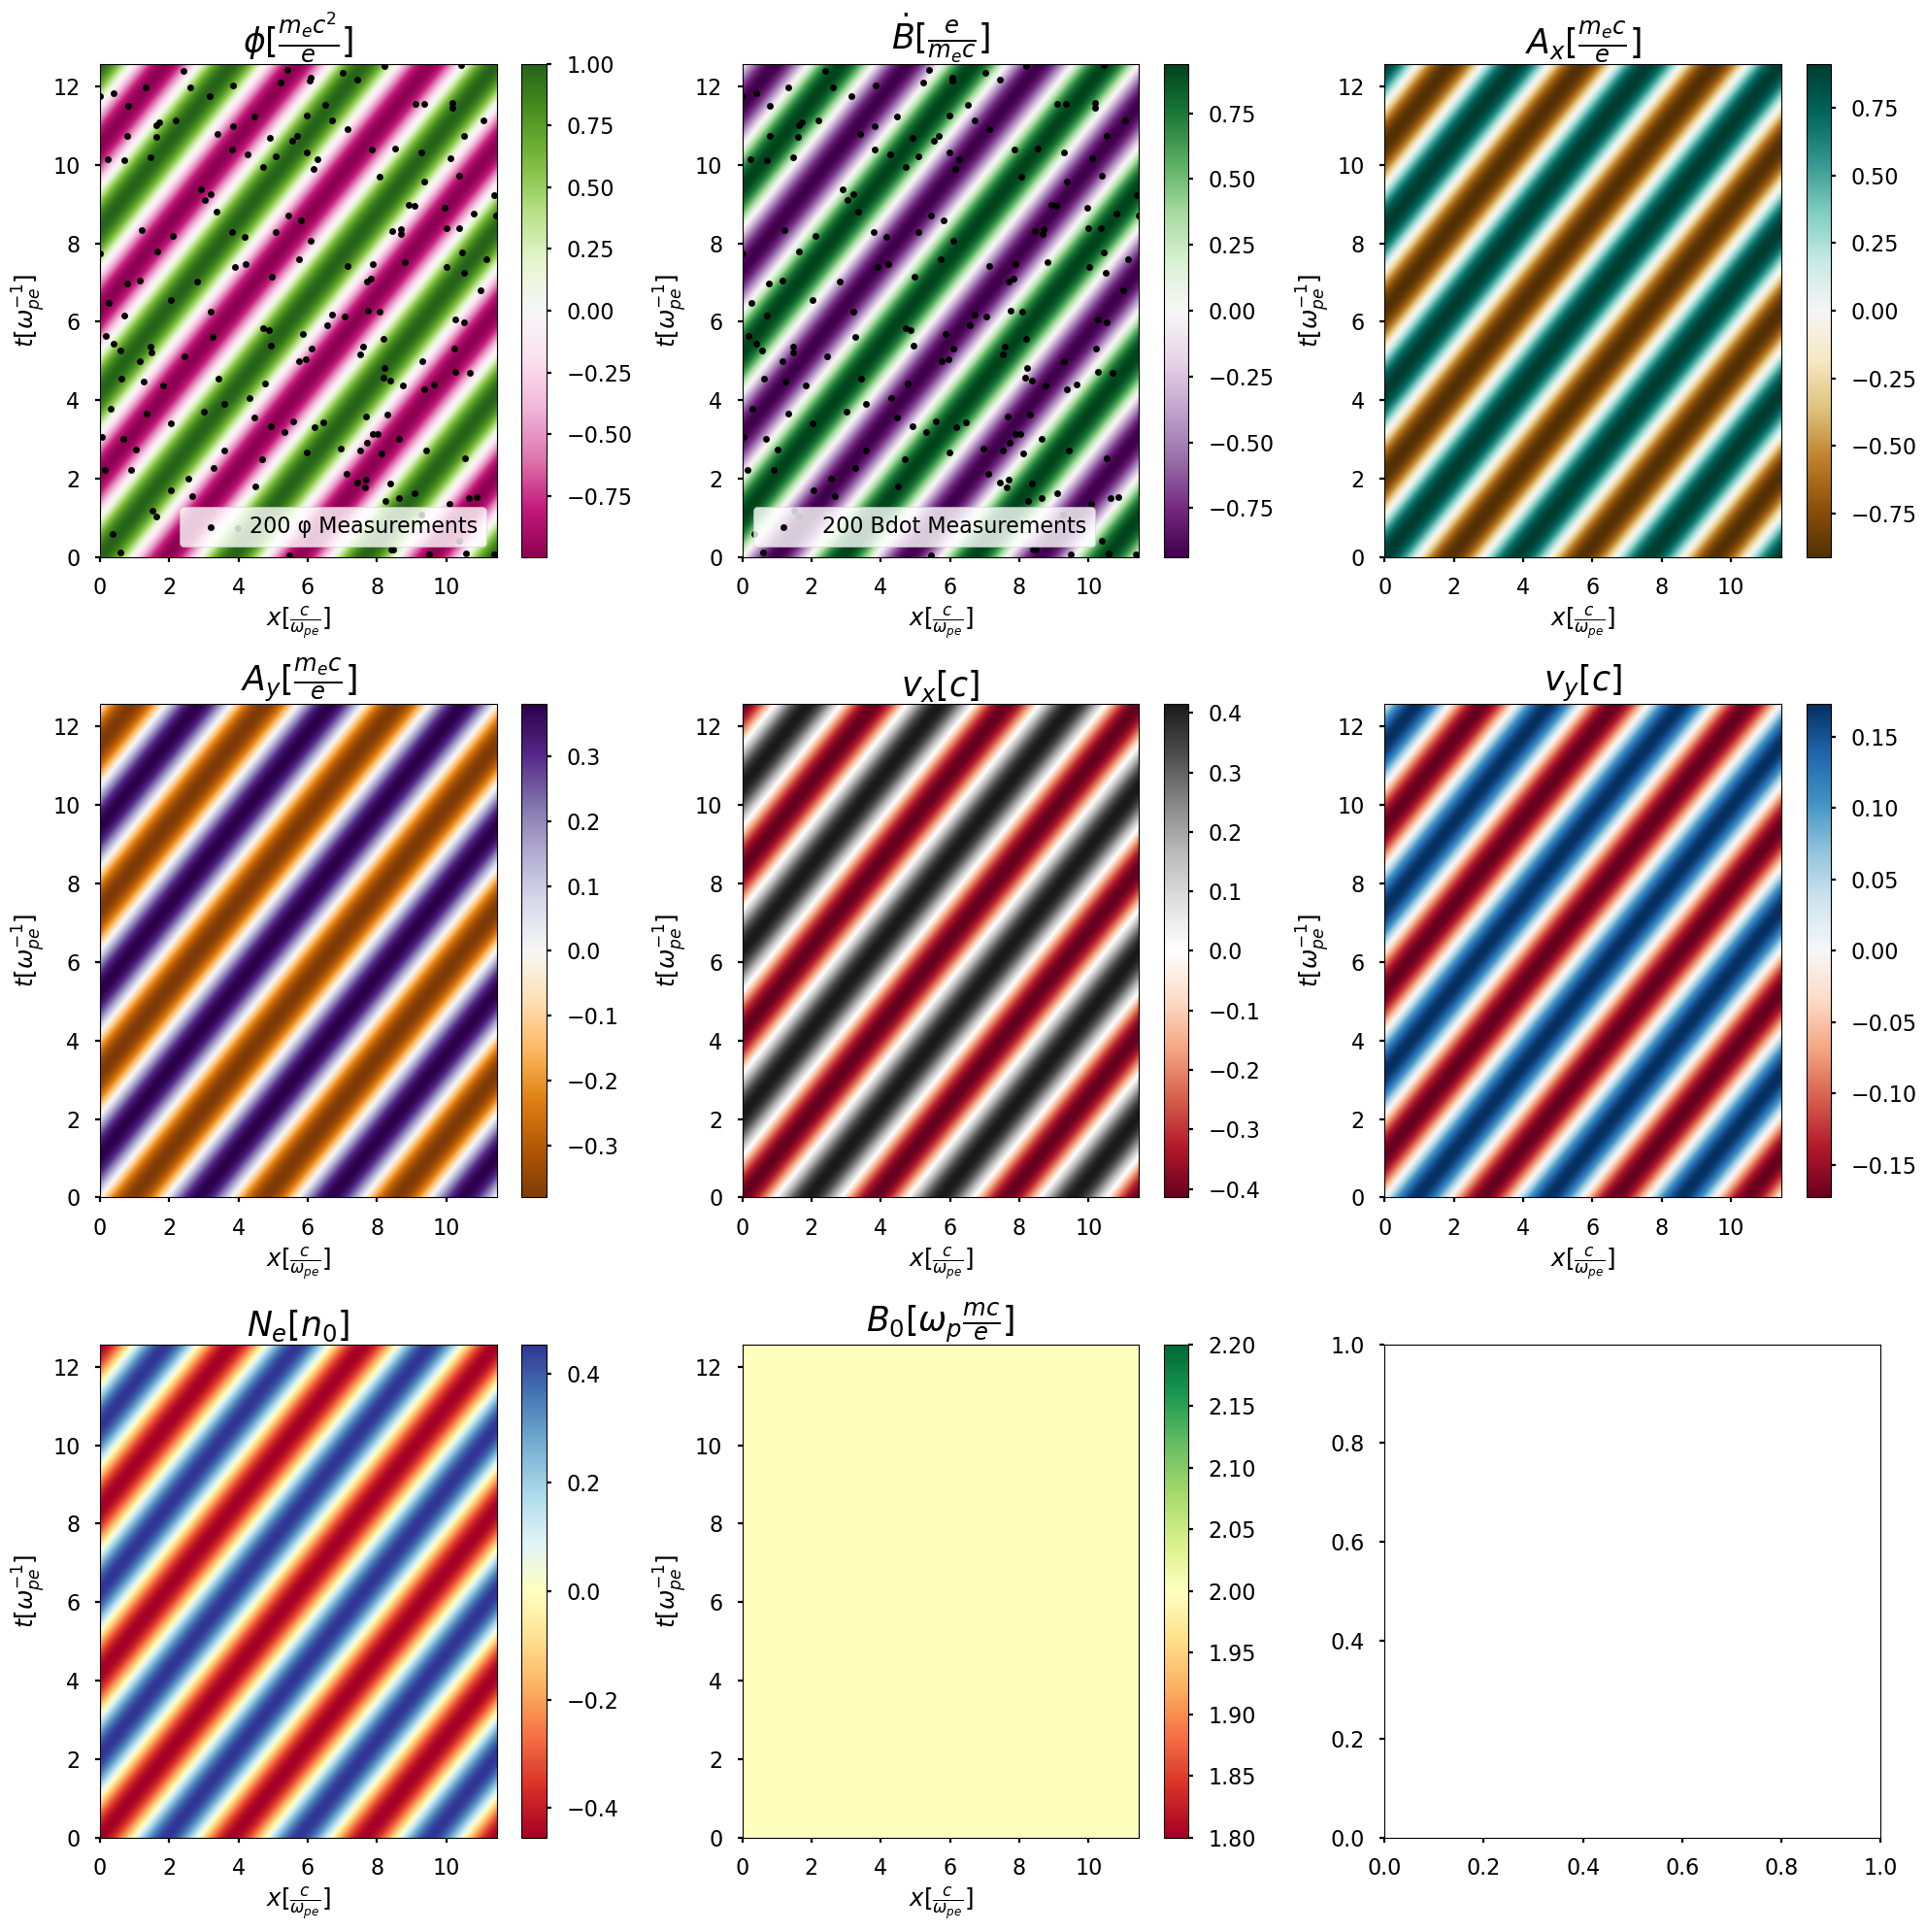

<Figure size 1280x880 with 0 Axes>

In [5]:
quantities_flat = np.array([phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat, B0_flat]) #Still complex quantities
extent_GT = [xmin, xmax, tmin, tmax]                                            #Extent of the ground truth values
quantities_GT = [x.reshape(Nt, Nx) for x in quantities_flat]            #Take the real part and Reshape to 2D arrays in the shape of the collocation points
quantities_GT_real = [np.real(x) for x in quantities_GT]                                  #Take the real part of the ground truth values
sparse = [x_sparse, t_sparse, phi_sparse, Bdot_sparse]                          #sparse phi and Bdot measurements (complex)
sparse_real = [np.real(x) for x in sparse]                                      #Take the real part of the sparse measurements      
titles_GT = [f'$\phi [\\frac{{m_{{e}}c^2}}{{e}}]$', 
            f'$\dot{{B}} [\\frac{{e}}{{m_{{e}}c}}]$',
            f'$A_x [\\frac{{m_{{e}}c}}{{e}}]$',
            f'$A_y [\\frac{{m_{{e}}c}}{{e}}]$',
            f'$v_x [c]$', 
            f'$v_y [c]$', 
            f'$N_e [n_0]$',
            r'$B_0 [\omega_p \frac{mc}{e}]$']

#Plot Ground Truth Values
print("-------Plotting Ground Truth Values-------------")
plot_analytical(quantities=quantities_GT_real, sparse = sparse_real, titles = titles_GT, extent = extent_GT, show_sparse=True)

Plotting the Constraints to make sure our "ground truths" satisfy the physics

In [6]:
def plot_constraints(constraints, titles, extent):
    "Plots the constraints in their current form."
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(20, 20))
    
    #adjusted titles to remove the average
    # adjusted_titles = [r'$|\partial_t V_x - \partial_t A_{1x} - \partial_x \phi + V_y B_0|$',
                    #    r'$|\partial_t V_y - \partial_t A_{1y} - V_x B_0|$']
    adjusted_titles = []
    
    for ax, constraint, title in zip(axes.flatten(), constraints, titles):
        
        #make a copy to avoid modifying the original constraint
        plot_data = np.abs(constraint.copy())
        
        if title in adjusted_titles:
            mean_value = np.mean(plot_data)
            plot_data -= mean_value  # Remove the mean value from the constraint
            print(f"Adjusting title: {title} by subtracting mean value: {mean_value:.4f}")
            
        im = ax.imshow(plot_data, aspect='auto', extent=extent, origin='lower', cmap='Reds')
        ax.set_title(title, fontsize = 15)
        ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
        ax.set_ylabel('$t [\\omega_{{pe}}^{{-1}}]$')
        fig.colorbar(im, ax=ax)
        
    
    plt.tight_layout()
    plt.show()
    

<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_102478/1300660326.py:22: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')


<>:35: SyntaxWarning: invalid escape sequence '\o'
<>:35: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_102478/2549777371.py:35: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')


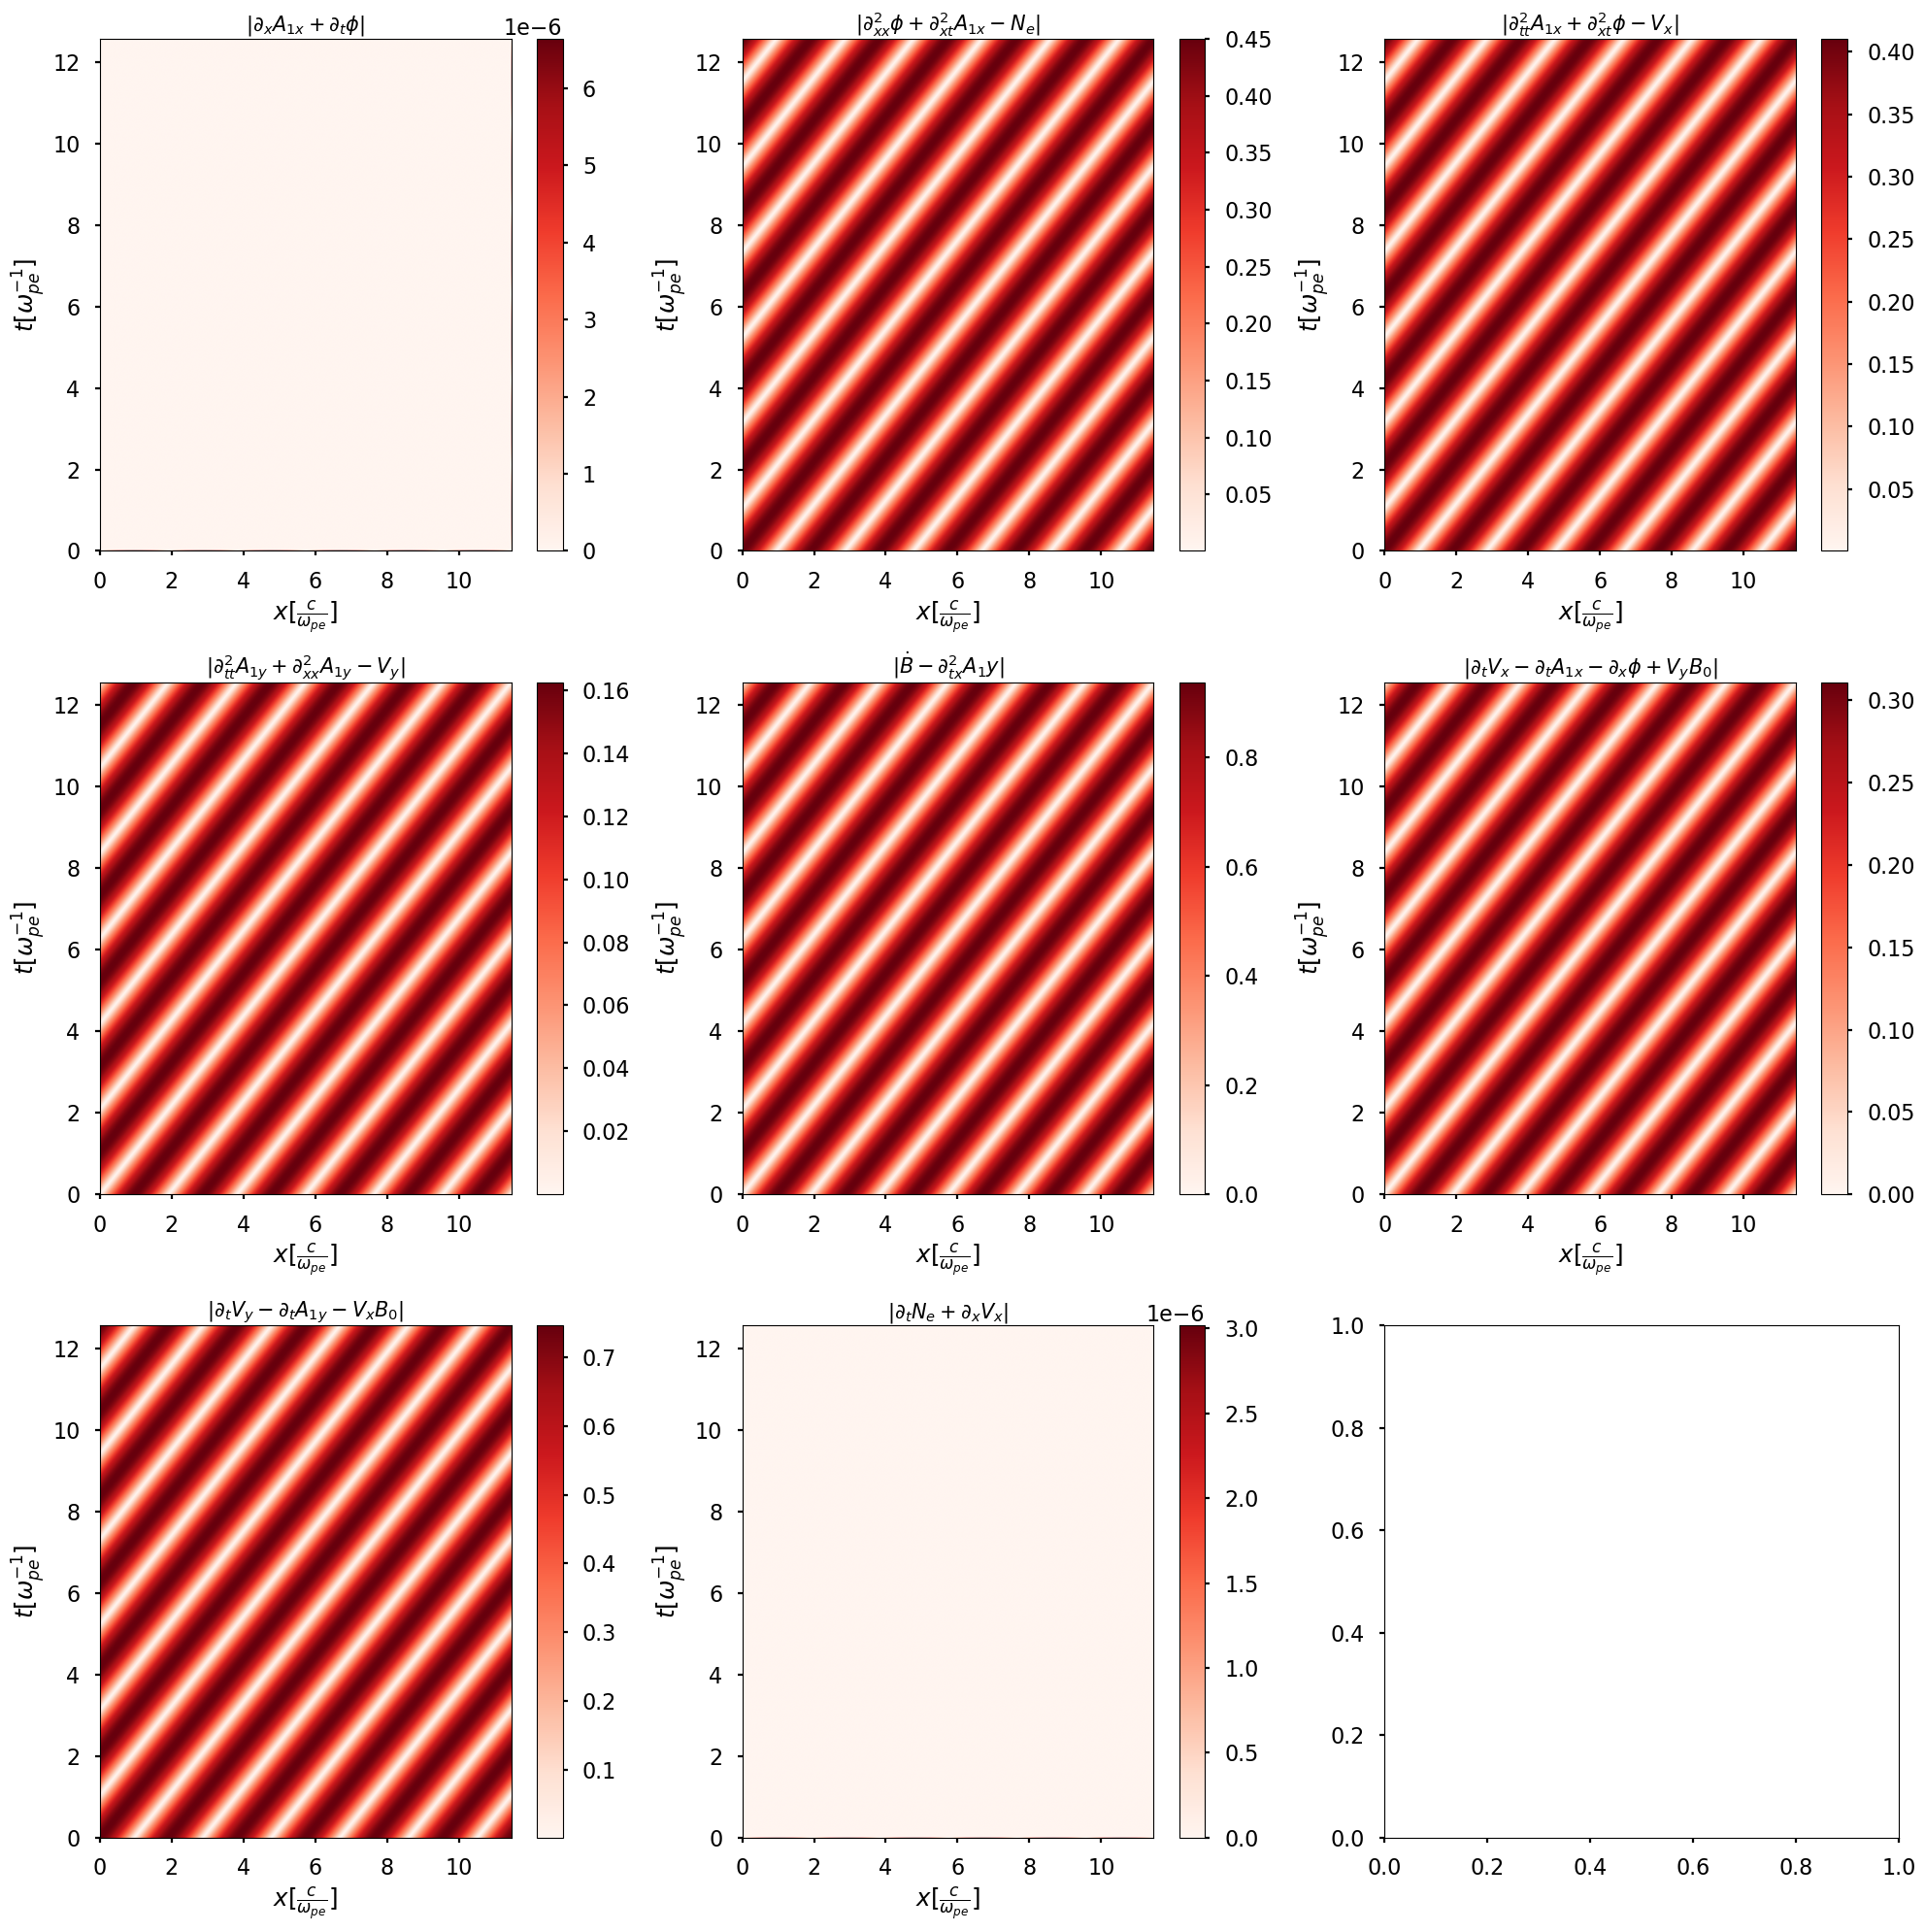

In [7]:
#Plot constraints

#GT values in complex form and reshpaed to 2D arrays
phi = np.array(quantities_GT[0])
Bdot = np.array(quantities_GT[1])
Ax = np.array(quantities_GT[2])
Ay = np.array(quantities_GT[3])
Vx = np.array(quantities_GT[4])
Vy = np.array(quantities_GT[5])
N = np.array(quantities_GT[6])
B0 = np.array(quantities_GT[7])

def plot_constraints(constraints, titles, extent):
    "Plots the constraints in their current form."
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
    
    #adjusted titles to remove the average
    # adjusted_titles = [r'$|\partial_t V_x - \partial_t A_{1x} - \partial_x \phi + V_y B_0|$',
    #                    r'$|\partial_t V_y - \partial_t A_{1y} - V_x B_0|$']
    adjusted_titles = []
    for ax, constraint, title in zip(axes.flatten(), constraints, titles):
        
        #make a copy to avoid modifying the original constraint
        plot_data = np.abs(constraint.copy()) 
        
        if title in adjusted_titles:
            mean_value = np.mean(np.abs(plot_data))
            plot_data -= mean_value  # Remove the mean value from the constraint
            plot_data = np.abs(plot_data)  # Ensure we are plotting the absolute value
            print(f"Adjusting title: {title} by subtracting mean value: {mean_value:.4f}")
        
            
        im = ax.imshow(plot_data, aspect='auto', extent=extent, origin='lower', cmap='Reds')
        ax.set_title(title, fontsize = 15)
        ax.set_xlabel(f'$x [\\frac{{c}}{{\omega_{{pe}}}}]$')
        ax.set_ylabel('$t [\\omega_{{pe}}^{{-1}}]$')
        fig.colorbar(im, ax=ax)
        
    
    plt.tight_layout()
    plt.show()

def spectral_derivatives_2d(f, t, x, deriv_type='x', filter_factor = .5):
    """
    Computes a partial derivative of a 2D function f(t, x) using the spectral method.

    Args:
        f (np.ndarray): A 2D numpy array representing the function f(t, x).
                        The first dimension is time, the second is space.
        t (np.ndarray): 1D array of time points.
        x (np.ndarray): 1D array of spatial points.
        deriv_type (str): The type of derivative to compute ('t', 'x', 'tt', 'xx', 'xt').

    Returns:
        np.ndarray: A 2D array containing the computed partial derivative.
    """
    Nt, Nx = f.shape
    dt = t[1] - t[0]
    dx = x[1] - x[0]

    # Perform 2D FFT to move to the frequency domain
    f_hat = np.fft.fft2(f)

    # Generate wave number arrays for time (omega) and space (k)
    omega = 2 * np.pi * np.fft.fftfreq(Nt, d=dt)
    k = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
    omega_grid, k_grid = np.meshgrid(omega, k, indexing='ij')

    # Add filtering to remove high-frequency noise
    f_hat_filtered = np.zeros_like(f_hat)
    num_to_keep_t = int(Nt * filter_factor)
    num_to_keep_x = int(Nx * filter_factor)

    # Filter by keeping only the central low-frequency modes
    f_hat_filtered[0:num_to_keep_t//2, 0:num_to_keep_x//2] = f_hat[0:num_to_keep_t//2, 0:num_to_keep_x//2]
    f_hat_filtered[-num_to_keep_t//2:, 0:num_to_keep_x//2] = f_hat[-num_to_keep_t//2:, 0:num_to_keep_x//2]
    f_hat_filtered[0:num_to_keep_t//2, -num_to_keep_x//2:] = f_hat[0:num_to_keep_t//2, -num_to_keep_x//2:]
    f_hat_filtered[-num_to_keep_t//2:, -num_to_keep_x//2:] = f_hat[-num_to_keep_t//2:, -num_to_keep_x//2:]


    # Apply the appropriate differentiation rule in the frequency domain
    if deriv_type == 'x':
        deriv_hat = 1j * k_grid * f_hat
    elif deriv_type == 't':
        deriv_hat = 1j * omega_grid * f_hat
    elif deriv_type == 'xx':
        deriv_hat = -(k_grid**2) * f_hat
    elif deriv_type == 'tt':
        deriv_hat = -(omega_grid**2) * f_hat
    elif deriv_type == 'xt':
        deriv_hat = -(omega_grid * k_grid) * f_hat
    else:
        raise ValueError("Invalid derivative type. Choose from 'x', 't', 'xx', 'tt', 'xt'.")

    # Perform 2D inverse FFT to return to the spatial domain
    deriv = np.fft.ifft2(deriv_hat)

    return deriv.real

def analytical_derivative(f, deriv_type = 'x'):
    """Computes the analytical derivative of a wave function f(t, x) based on the wave equation.
    f is of the form f(t, x) ~ exp(i(k*x - omega*t + delta))
    then returns the resulting complex function."""
    
    temp = f
    if deriv_type == 'x':
        temp = 1j*k * temp  
    elif deriv_type == 't':
        temp = (-1j*omega) * temp
    elif deriv_type == 'xx':
        temp = -(k**2) * temp
    elif deriv_type == 'tt':
        temp = -(omega**2) * temp
    elif deriv_type == 'xt':
        temp = omega*k * temp
    
    return temp


def analytical_solution_torch(x, t, omega:float, k:float, phi_amp:float, delta):
    
    phi_amp *= phase_factor(delta)
    
    B0_sq_num = ((omega**2)-(k**2)-1)*((omega**2)-1)
    B0_sq_denom = ((omega**2)-(k**2))
    B0 = np.sqrt(B0_sq_num / B0_sq_denom)  #Required B0 to ensure momentum constraints satisfied             
    
    A1y_amp  = 1j*(phi_amp/B0)*(((omega**2)/k) - (1/k))                                            #Required A1y amp to ensure momentum constraints satisfied
    
    phase = np.exp(1j*(k*x - omega*t))
    
    phi = phi_amp * phase # Perturbed scalar potential phi)
    
    # Perturbed Vector Potential A1
    A1x = (omega/k)*phi
    A1y = A1y_amp * torch.exp(1j * phase)  
    
    # Electron density perturbation N = n_e - n_0
    N = ((omega**2) - (k**2))*phi
    
    # Perturbed electron velocities v1
    vx = (omega/k)*((omega**2) - (k**2))*phi
    vy = ((omega**2) - (k**2))*A1y
    
    # Time derivative of perturbed B field (from curl of A1)
    Bdot = omega*k*A1y
    
    #Background field B0 is constant.
    B0_value = B0.expand_as(Bdot)
     
    return phi, Bdot, A1x, A1y, vx, vy, N, B0_value

# #spatial derivatives use 1 and temporal use 0
phi_x_grad = np.gradient(phi, dx, axis=1, edge_order = 2) 
phi_xx_grad = np.gradient(phi_x_grad, dx, axis=1, edge_order = 2) 
phi_t_grad = np.gradient(phi, dt, axis=0, edge_order = 2) 
phi_tt_grad = np.gradient(phi_t_grad, dt, axis=0, edge_order = 2) 
phi_xt_grad = np.gradient(phi_x_grad, dt, axis=0, edge_order = 2)

Ax_x_grad = np.gradient(Ax, dx, axis=1, edge_order = 2)
Ax_xx_grad = np.gradient(Ax_x_grad, dx, axis=1, edge_order = 2) 
Ax_t_grad = np.gradient(Ax, dt, axis=0, edge_order = 2)
Ax_tt_grad = np.gradient(Ax_t_grad, dt, axis=0, edge_order = 2)
Ax_xt_grad = np.gradient(Ax_x_grad, dt, axis=0, edge_order = 2) 
Ay_x_grad = np.gradient(Ay, dx, axis=1, edge_order = 2) 
Ay_xx_grad = np.gradient(Ay_x_grad, dx, axis=1, edge_order = 2) 
Ay_t_grad = np.gradient(Ay, dt, axis=0, edge_order = 2)
Ay_tt_grad = np.gradient(Ay_t_grad, dt, axis=0, edge_order = 2) 
Ay_xt_grad = np.gradient(Ay_x_grad, dt, axis=0, edge_order = 2)

Vx_x_grad = np.gradient(Vx, dx, axis=1, edge_order = 2) 
Vx_t_grad = np.gradient(Vx, dt, axis=0, edge_order = 2)
Vy_x_grad = np.gradient(Vy, dx, axis=1, edge_order = 2)
Vy_t_grad = np.gradient(Vy, dt, axis=0, edge_order = 2) 

N_t_grad = np.gradient(N, dt, axis=0, edge_order = 2)

#Finite Difference derivatives
phi_x = derivative_x(phi, dx)
phi_xx = derivative_xx(phi, dx)
phi_t = derivative_t(phi, dt)
phi_tt = derivative_tt(phi, dt)
phi_xt = derivative_xt(phi, dx=dx, dt=dt)

Ax_x = derivative_x(Ax, dx)
Ax_xx = derivative_xx(Ax, dx)
Ax_t = derivative_t(Ax, dt)
Ax_tt = derivative_tt(Ax, dt)
Ax_xt = derivative_xt(Ax, dx=dx, dt=dt)
Ay_x = derivative_x(Ay, dx)
Ay_xx = derivative_xx(Ay, dx)
Ay_t = derivative_t(Ay, dt)
Ay_tt = derivative_tt(Ay_t, dt)
Ay_xt = derivative_xt(Ay, dx=dx, dt=dt)

Vx_x = derivative_x(Vx, dx)
Vx_t = derivative_t(Vx, dt)
Vy_x = derivative_x(Vy, dx)
Vy_t = derivative_t(Vy, dt)

N_t = derivative_t(N, dt)

# #Spectral derivatives
# phi_x_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='x')
# phi_xx_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xx')
# phi_t_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='t')
# phi_tt_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='tt')
# phi_xt_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xt')

# Ax_x_spectral = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='x')
# Ax_xx_spectral = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='xx')
# Ax_t_spectral = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='t')
# Ax_tt_spectral = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='tt')
# Ax_xt_spectral = spectral_derivatives_2d(Ax, x_arr, t_arr, deriv_type='xt')
# Ay_x_spectral = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='x')
# Ay_xx_spectral = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='xx')
# Ay_t_spectral = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='t')
# Ay_tt_spectral = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='tt')
# Ay_xt_spectral = spectral_derivatives_2d(Ay, x_arr, t_arr, deriv_type='xt')

# Vx_x_spectral = spectral_derivatives_2d(Vx, x_arr, t_arr, deriv_type='x')
# Vx_t_spectral = spectral_derivatives_2d(Vx, x_arr, t_arr, deriv_type='t')
# Vy_x_spectral = spectral_derivatives_2d(Vy, x_arr, t_arr, deriv_type='x')
# Vy_t_spectral = spectral_derivatives_2d(Vy, x_arr, t_arr, deriv_type='t')

# N_t_spectral = spectral_derivatives_2d(N, x_arr, t_arr, deriv_type='t')

# phi_x_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='x')
# phi_xx_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xx')
# phi_t_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='t')
# phi_tt_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='tt')
# phi_xt_spectral = spectral_derivatives_2d(phi, x_arr, t_arr, deriv_type='xt')


#Analytical Derivatives
# phi_x_analytical = analytical_derivative(phi, deriv_type='x')
# phi_xx_analytical = analytical_derivative(phi, deriv_type='xx')
# phi_t_analytical = analytical_derivative(phi, deriv_type='t')
# phi_tt_analytical = analytical_derivative(phi, deriv_type='tt')
# phi_xt_analytical = analytical_derivative(phi, deriv_type='xt')

# Ax_x_analytical = analytical_derivative(Ax, deriv_type='x')
# Ax_xx_analytical = analytical_derivative(Ax, deriv_type='xx')
# Ax_t_analytical = analytical_derivative(Ax, deriv_type='t')
# Ax_tt_analytical = analytical_derivative(Ax, deriv_type='tt')
# Ax_xt_analytical = analytical_derivative(Ax, deriv_type='xt')
# Ay_x_analytical = analytical_derivative(Ay, deriv_type='x')
# Ay_xx_analytical = analytical_derivative(Ay, deriv_type='xx')
# Ay_t_analytical = analytical_derivative(Ay, deriv_type='t')
# Ay_tt_analytical = analytical_derivative(Ay, deriv_type='tt')
# Ay_xt_analytical = analytical_derivative(Ay, deriv_type='xt')

# Vx_x_analytical = analytical_derivative(Vx, deriv_type='x')
# Vx_t_analytical = analytical_derivative(Vx, deriv_type='t')
# Vy_x_analytical = analytical_derivative(Vy, deriv_type='x')
# Vy_t_analytical = analytical_derivative(Vy, deriv_type='t')

# N_t_analytical = analytical_derivative(N, deriv_type='t')


#Torch.autograd derivatves
# x_coll_torch = torch.tensor(X_arr, dtype=torch.float64, requires_grad=True)
# t_coll_torch = torch.tensor(T_arr, dtype=torch.float64, requires_grad=True)
# phi_torch, Bdot_torch, Ax_torch, Ay_torch, Vx_torch, Vy_torch, N_torch, B0_torch = analytical_solution_torch(x_coll_torch, t_coll_torch, k, omega, phi_amp, torch.tensor(delta_list[0]))
# values_gt_torch = [phi_torch, Bdot_torch, Ax_torch, Ay_torch, Vx_torch, Vy_torch, N_torch, B0_torch]
# phi_torch, Bdot_torch, Ax_torch, Ay_torch, Vx_torch, Vy_torch, N_torch, B0_torch = [torch.real(x) for x in values_gt_torch]  # Ensure all values are real

# phi_x_torch = torch.autograd.grad(phi_torch, x_coll_torch, grad_outputs=torch.ones_like(phi_torch), create_graph=True)[0]
# phi_xx_torch = torch.autograd.grad(phi_x_torch, x_coll_torch, grad_outputs=torch.ones_like(phi_x_torch), create_graph=True)[0]
# phi_t_torch = torch.autograd.grad(phi_torch, t_coll_torch, grad_outputs=torch.ones_like(phi_torch), create_graph=True)[0]
# phi_tt_torch = torch.autograd.grad(phi_t_torch, t_coll_torch, grad_outputs=torch.ones_like(phi_t_torch), create_graph=True)[0]
# phi_xt_torch = torch.autograd.grad(phi_x_torch, t_coll_torch, grad_outputs=torch.ones_like(phi_x_torch), create_graph=True)[0]

# Ax_x_torch = torch.autograd.grad(Ax_torch, x_coll_torch, grad_outputs=torch.ones_like(Ax_torch), create_graph=True)[0]
# Ax_xx_torch = torch.autograd.grad(Ax_x_torch, x_coll_torch, grad_outputs=torch.ones_like(Ax_x_torch), create_graph=True)[0]
# Ax_t_torch = torch.autograd.grad(Ax_torch, t_coll_torch, grad_outputs=torch.ones_like(Ax_torch), create_graph=True)[0]
# Ax_tt_torch = torch.autograd.grad(Ax_t_torch, t_coll_torch, grad_outputs=torch.ones_like(Ax_t_torch), create_graph=True)[0]
# Ax_xt_torch = torch.autograd.grad(Ax_x_torch, t_coll_torch, grad_outputs=torch.ones_like(Ax_x_torch), create_graph=True)[0]

# Ay_x_torch = torch.autograd.grad(Ay_torch, x_coll_torch, grad_outputs=torch.ones_like(Ay_torch), create_graph=True)[0]
# Ay_xx_torch = torch.autograd.grad(Ay_x_torch, x_coll_torch, grad_outputs=torch.ones_like(Ay_x_torch), create_graph=True)[0]
# Ay_t_torch = torch.autograd.grad(Ay_torch, t_coll_torch, grad_outputs=torch.ones_like(Ay_torch), create_graph=True)[0]
# Ay_tt_torch = torch.autograd.grad(Ay_t_torch, t_coll_torch, grad_outputs=torch.ones_like(Ay_t_torch), create_graph=True)[0]
# Ay_xt_torch = torch.autograd.grad(Ay_x_torch, t_coll_torch, grad_outputs=torch.ones_like(Ay_x_torch), create_graph=True)[0]

# Vx_x_torch = torch.autograd.grad(Vx_torch, x_coll_torch, grad_outputs=torch.ones_like(Vx_torch), create_graph=True)[0]
# Vx_t_torch = torch.autograd.grad(Vx_torch, t_coll_torch, grad_outputs=torch.ones_like(Vx_torch), create_graph=True)[0]
# Vy_x_torch = torch.autograd.grad(Vy_torch, x_coll_torch, grad_outputs=torch.ones_like(Vy_torch), create_graph=True)[0]
# Vy_t_torch = torch.autograd.grad(Vy_torch, t_coll_torch, grad_outputs=torch.ones_like(Vy_torch), create_graph=True)[0]

# N_t_torch = torch.autograd.grad(N_torch, t_coll_torch, grad_outputs=torch.ones_like(N_torch), create_graph=True)[0] 



# Constraints
gauge = Ax_x + phi_t                                #Gauge
gauss = phi_xx - phi_tt - N                     #gauss
ampere_x = Ax_xx - Ax_tt - Vx                       #ampere_x
ampere_y = Ay_xx - Ay_tt - Vy                        #ampere_y
bdot_curlA = Bdot - Ay_xt                           #time derivative of definition of A
momentum_x = Vx_t - Ax_t - phi_x + Vy*B0            #momentum x direction (PROBLEM)
momentum_y = Vy_t - Ay_t - Vx*B0                    #momentum y direction (PROBLEM)
continuity = N_t + Vx_x                             #continuity

# gauge = Ax_x_analytical + phi_t_analytical                                                      #Gauge
# gauss = phi_xx_analytical - phi_tt_analytical - N                                       #gauss
# ampere_x = Ax_xx_analytical - Ax_tt_analytical - Vx                                   #ampere_x
# ampere_y = Ay_xx_analytical - Ay_tt_analytical - Vy                                    #ampere_y
# bdot_curlA = Bdot - Ay_xt_analytical                                                            #time derivative of definition of A
# momentum_x = Vx_t_analytical - Ax_t_analytical - phi_x_analytical + Vy*B0                       #momentum x direction
# momentum_y = Vy_t_analytical - Ay_t_analytical - Vx*B0                                          #momentum y direction
# continuity = N_t_analytical + Vx_x_analytical                                                   #continuity


# gauge = Ax_x_torch + phi_t_torch                                                            #Gauge
# gauss = phi_xx_torch + Ax_xt_torch - N_torch                                                #gauss
# ampere_x = Ax_tt_torch + phi_xt_torch + Vx_torch                                            #ampere_x
# ampere_y = Ay_tt_torch - Ay_xx_torch + Vy_torch                                             #ampere_y
# # # wave_Ax = Ax_xx_torch - Ax_tt_torch - Vx_torch                                            ##Wave equation for Ax
# # # wave_Ay = Ay_xx_torch - Ay_tt_torch - Vy_torch                                            ##Wave equation for Ay
# # # wave_phi = phi_xx_torch - phi_tt_torch - N_torch                                          ##Wave equation for phi
# bdot_curlA = Bdot_torch - Ay_xt_torch                                                       #time derivative of definition of A
# momentum_x = Vx_t_torch - Ax_t_torch - phi_x_torch + Vy_torch*B0_torch                      #momentum x direction
# momentum_y = Vy_t_torch - Ay_t_torch - Vx_torch*B0_torch                                    #momentum y direction
# continuity = N_t_torch + Vx_x_torch                                                         #continuity

#Define the 2d grid shape
Nt = len(np.unique(T_arr))
Nx = len(np.unique(X_arr))
grid_shape = (Nt, Nx)

# constraints_torch = [gauge.reshape(grid_shape), gauss.reshape(grid_shape),
#                     ampere_x.reshape(grid_shape), ampere_y.reshape(grid_shape),
#                     bdot_curlA.reshape(grid_shape),
#                     momentum_x.reshape(grid_shape), momentum_y.reshape(grid_shape),
#                     continuity.reshape(grid_shape)]
# consraints_torch_to_np = [c.detach().numpy() for c in constraints_torch]  # Convert to numpy arrays for plotting



constraints = [gauge, gauss, ampere_x, ampere_y,
                bdot_curlA, momentum_x, momentum_y, continuity]
constraints_real = [np.real(c) for c in constraints]  # Take the real part of the constraints for plotting

constraint_titles = [r'$|\partial_x A_{1x} + \partial_t \phi|$',                            #gauge
                    r'$|\partial_{xx}^2 \phi + \partial_{xt}^2 A_{1x} - N_e|$',             #gauss_law
                    r'$|\partial_{tt}^2 A_{1x} + \partial_{xt}^2 \phi - V_x|$',             #ampere_x
                    r'$|\partial_{tt}^2 A_{1y} + \partial_{xx}^2 A_{1y} - V_y|$',           #ampere_y
                    # r'$|\partial_{xx}^2 A_{1x} - \partial_{tt}^2 A_{1x} - V_x|$',         ##wave equation for Ax   
                    # r'$|\partial_{xx}^2 A_{1y} - \partial_{tt}^2 A_{1y} - V_y|$',         ##wave equation for Ay
                    # r'$|\partial_{xx}^2 \phi - \partial_{tt}^2 \phi - N_e|$',             ##wave equation for phi
                    r'$|\dot{B} - \partial_{tx}^2 A_1y|$',                                  #Time derivative of definition of A
                    r'$|\partial_t V_x - \partial_t A_{1x} - \partial_x \phi + V_y B_0|$',  #momentum x direction
                    r'$|\partial_t V_y - \partial_t A_{1y} - V_x B_0|$',                    #momentum y direction
                    r'$|\partial_t N_e + \partial_x V_x|$']                                 #continuity
# constraint_titles = list(np.linspace(1,11,11))
plot_constraints(constraints=constraints_real, titles=constraint_titles, extent = extent_GT)

In [8]:
# phi = quantities_GT[0]
# Bdot= quantities_GT[1]
# Ax = quantities_GT[2]
# Ay = quantities_GT[3]
# Vx = quantities_GT[4]
# Vy = quantities_GT[5]
# N = quantities_GT[6]


# #Numerical Derivatives
phi_x = derivative_x(phi, dx)
phi_xx = derivative_x(phi_x, dx)
phi_t = derivative_t(phi, dt)
phi_tt = derivative_t(phi_t, dt)
phi_xt = derivative_t(phi_x, dt)

Ax_x = derivative_x(Ax, dx)
Ax_xx = derivative_x(Ax_x, dx)
Ax_t = derivative_t(Ax, dt)
Ax_tt = derivative_t(Ax_t, dt)
Ax_xt = derivative_t(Ax_x, dx)
Ay_x = derivative_x(Ay, dx)
Ay_xx = derivative_x(Ay_x, dx)
Ay_t = derivative_t(Ay, dt)
Ay_tt = derivative_t(Ay_t, dt)
Ay_xt = derivative_t(Ay_x, dt)

Vx_x = derivative_x(Vx, dx)
Vx_t = derivative_t(Vx, dt)
Vy_x = derivative_x(Vy, dx)
Vy_t = derivative_t(Vy, dt)

N_t = derivative_t(N, dt)

num_sols = [phi_x, phi_xx, phi_t, phi_tt, phi_xt,
            Ax_x, Ax_xx, Ax_t, Ax_tt, Ax_xt,
            Ay_x, Ay_xx, Ay_t, Ay_tt, Ay_xt,
            Vx_x, Vx_t, Vy_x, Vy_t, N_t]

analytical_sols = np.real(np.array([phi_x_analytical, phi_xx_analytical, phi_t_analytical, phi_tt_analytical, phi_xt_analytical,
            Ax_x_analytical, Ax_xx_analytical, Ax_t_analytical, Ax_tt_analytical, Ax_xt_analytical,
            Ay_x_analytical, Ay_xx_analytical, Ay_t_analytical, Ay_tt_analytical, Ay_xt_analytical,
            Vx_x_analytical, Vx_t_analytical, Vy_x_analytical, Vy_t_analytical, N_t_analytical]))

# torch_sols = np.real(np.array([phi_x_torch.detach().numpy().reshape(grid_shape), phi_xx_torch.detach().numpy().reshape(grid_shape), phi_t_torch.detach().numpy().reshape(grid_shape), phi_tt_torch.detach().numpy().reshape(grid_shape), phi_xt_torch.detach().numpy().reshape(grid_shape),
#             Ax_x_torch.detach().numpy().reshape(grid_shape), Ax_xx_torch.detach().numpy().reshape(grid_shape), Ax_t_torch.detach().numpy().reshape(grid_shape), Ax_tt_torch.detach().numpy().reshape(grid_shape), Ax_xt_torch.detach().numpy().reshape(grid_shape),
#             Ay_x_torch.detach().numpy().reshape(grid_shape), Ay_xx_torch.detach().numpy().reshape(grid_shape), Ay_t_torch.detach().numpy().reshape(grid_shape), Ay_tt_torch.detach().numpy().reshape(grid_shape), Ay_xt_torch.detach().numpy().reshape(grid_shape),
#             Vx_x_torch.detach().numpy().reshape(grid_shape), Vx_t_torch.detach().numpy().reshape(grid_shape), Vy_x_torch.detach().numpy().reshape(grid_shape), Vy_t_torch.detach().numpy().reshape(grid_shape), N_t_torch.detach().numpy().reshape(grid_shape)]))

# grad_sols = np.real(np.array([phi_x_grad, phi_xx_grad, phi_t_grad, phi_tt_grad, phi_xt_grad,
#                               Ax_x_grad, Ax_xx_grad, Ax_t_grad, Ax_tt_grad, Ax_xt_grad,
#                               Ay_x_grad, Ay_xx_grad, Ay_t_grad, Ay_tt_grad, Ay_xt_grad,
#                               Vx_x_grad, Vx_t_grad, Vy_x_grad, Vy_t_grad, N_t_grad]))

# spectral_sols = np.real(np.array([phi_x_spectral, phi_xx_spectral, phi_t_spectral, phi_tt_spectral, phi_xt_spectral,
#                                   Ax_x_spectral, Ax_xx_spectral, Ax_t_spectral, Ax_tt_spectral, Ax_xt_spectral,
#                                   Ay_x_spectral, Ay_xx_spectral, Ay_t_spectral, Ay_tt_spectral, Ay_xt_spectral,
#                                   Vx_x_spectral, Vx_t_spectral, Vy_x_spectral, Vy_t_spectral, N_t_spectral]))

titles_sols = ['phi_x', 'phi_xx', 'phi_t', 'phi_tt', 'phi_xt',
               'Ax_x', 'Ax_xx', 'Ax_t', 'Ax_tt', 'Ax_xt',
               'Ay_x', 'Ay_xx', 'Ay_t', 'Ay_tt', 'Ay_xt',
               'Vx_x', 'Vx_t', 'Vy_x', 'Vy_t', 'N_t']
def compare_derivs(analytical_sols, num_sols, titles, extent):
    # This creates a 5x4 grid, so axs is a 2D NumPy array of Axes objects.
    # I've changed it to 2x2 to match the mock data.
     # Create a 5x5 grid to accommodate all 21 derivatives
    fig, axs = plt.subplots(5, 5, figsize=(20, 20), constrained_layout=True)

    # Flatten the axes array to easily iterate
    axs = axs.flatten()

    for i, (analytical, numerical, title) in enumerate(zip(analytical_sols, num_sols, titles)):
        if i < len(axs):
            ax = axs[i]
            # Calculate the absolute difference between the solutions
            difference = np.abs(analytical - numerical)
            epsilon=1e-12
            rel_error = difference/(np.abs(analytical)+epsilon)
            percent_accuracy = (1-rel_error)*100
            mean_accuracy = np.mean(percent_accuracy)

            # Plot the difference using imshow
            im = ax.imshow(np.abs(difference), extent=extent, aspect='auto')
            fig.colorbar(im, ax=ax, label='Absolute Difference')

            ax.set_title(f'Absolute Difference: {title}')
            ax.set_xlabel('x')
            ax.set_ylabel('t')

    # Hide any unused subplots
    for j in range(len(analytical_sols), len(axs)):
        fig.delaxes(axs[j])


    plt.show()
    
def compare_derivs_1d(analytical_sols, num_sols, titles=titles_sols, extent=extent_GT):
    """For Every value in analytical_sols and num_sols, plot the absolute difference between them.
    on both the time and space domain."""
    
    fig, axs = plt.subplots(5, 4, figsize=(20, 20), constrained_layout=True)
    axs = axs.flatten()

    for i, (analytical, numerical, title) in enumerate(zip(analytical_sols, num_sols, titles)):
        if i < len(axs):
            ax = axs[i]
            difference = np.abs(analytical - numerical)
            epsilon=1e-12
            rel_error = difference/(np.abs(analytical)+epsilon)
            percent_accuracy = (1-rel_error)*100
            mean_accuracy = np.mean(percent_accuracy)

            im = ax.imshow(np.abs(difference), extent=extent, aspect='auto')
            fig.colorbar(im, ax=ax, label='Absolute Difference')

            ax.set_title(f'Absolute Difference: {title}')
            ax.set_xlabel('x')
            ax.set_ylabel('t')

    for j in range(len(analytical_sols), len(axs)):
        fig.delaxes(axs[j])

    plt.show()
compare_derivs(num_sols, analytical_sols, titles=titles_sols, extent=extent_GT)

NameError: name 'phi_x_analytical' is not defined

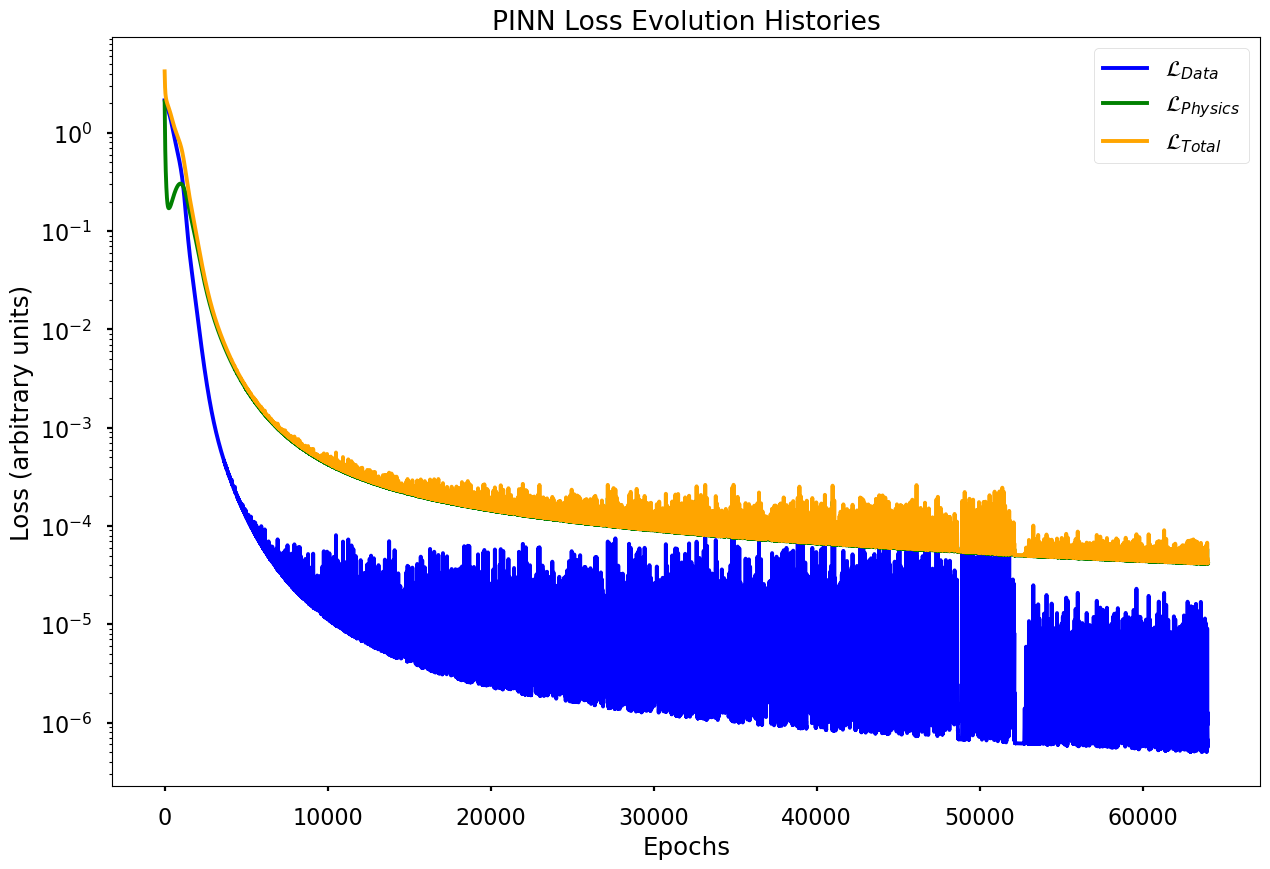

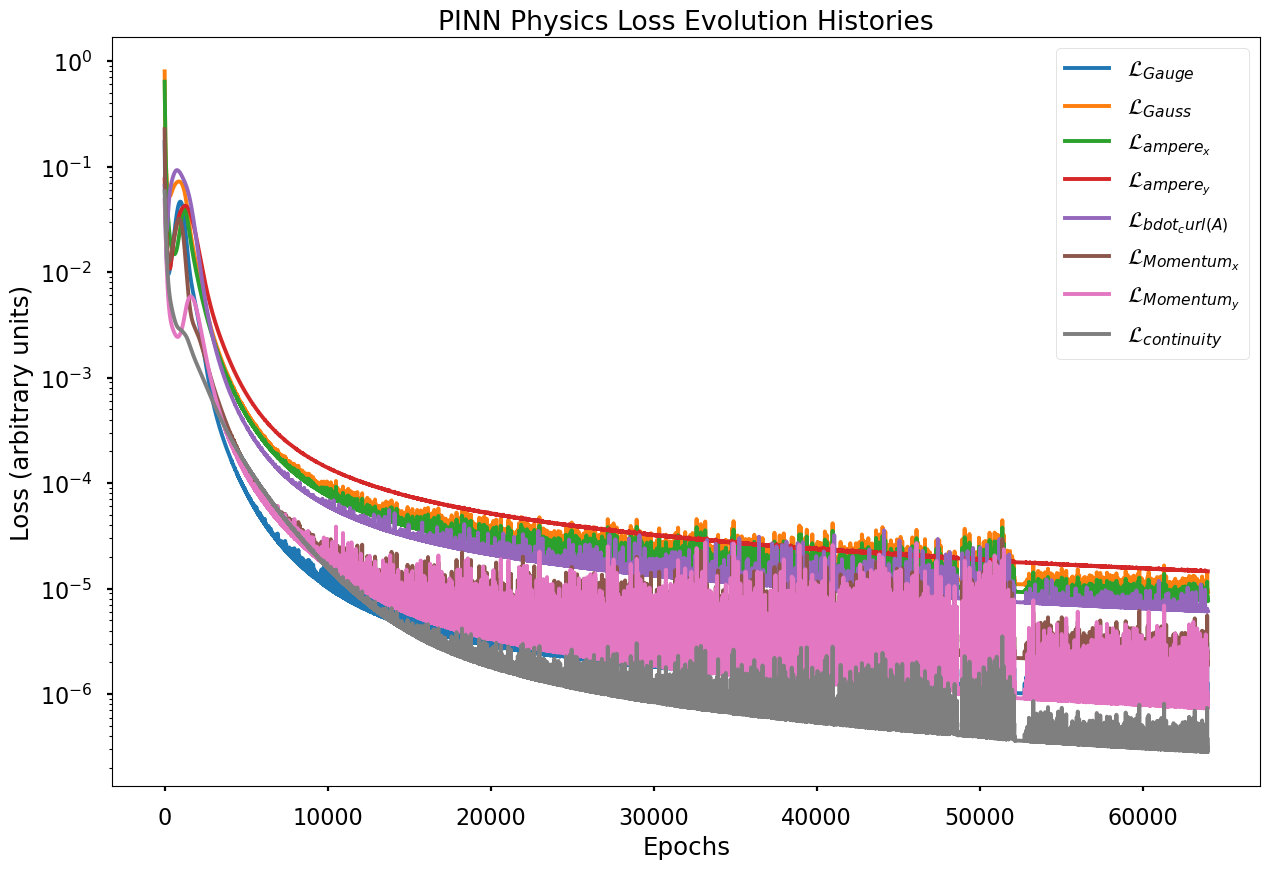

In [9]:
import pickle
from PINN_XWave_DDP import MLP
import torch


def plot_loss_histories(hist):
    "Total Loss, SM Loss, and Physics Loss histories."
    
    plt.figure()
    
    plt.title("PINN Loss Evolution Histories")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (arbitrary units)")
    
    plt.semilogy(hist['sm_loss'], label=r'$\mathcal{L}_{Data}$', color='blue')
    plt.semilogy(hist['physics_loss'], label=r'$\mathcal{L}_{Physics}$', color='green')
    plt.semilogy(hist['loss'], label=r'$\mathcal{L}_{Total}$', color='orange')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    #physics loss components
    
    plt.figure()
    plt.title("PINN Physics Loss Evolution Histories")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (arbitrary units)")
    
    plt.semilogy(hist['gauge_loss'], label=r'$\mathcal{L}_{Gauge}$')
    plt.semilogy(hist['gauss_loss'], label=r'$\mathcal{L}_{Gauss}$')
    plt.semilogy(hist['ampere_x_loss'], label=r'$\mathcal{L}_{ampere_{x}}$')
    plt.semilogy(hist['ampere_y_loss'], label = r'$\mathcal{L}_{ampere_{y}}$')
    plt.semilogy(hist['bdot_curlA_loss'], label=r'$\mathcal{L}_{bdot_curl(A)}$')
    plt.semilogy(hist['momentum_x_loss'], label=r'$\mathcal{L}_{Momentum_x}$')
    plt.semilogy(hist['momentum_y_loss'], label=r'$\mathcal{L}_{Momentum_y}$')
    plt.semilogy(hist['continuity_loss'], label=r'$\mathcal{L}_{continuity}$')    
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    # plt.savefig("XWave_loss_hist")
    
    return


with open('ddp_xwave_hist.pkl', 'rb') as f:
    history = pickle.load(f)

plot_loss_histories(history)

Validating the Model

In [10]:
# Load the model
# model_params = {
#     'extent': np.array([tmin, tmax, xmin, xmax]),
#     'num_hidden_layers': 1,
#     'hidden_size': 64,
#     'activation': 'sin',
#     'init': 'xavier',
#     'input_encoding': True,
#     'sigma': 1.0,
#     'device': torch.device("cpu"),
# }

# model = MLP(**model_params)
# model.load_state_dict(torch.load("ddp_xwave_model.pt", map_location=model_params['device']))
# model.eval()
# print("Model weights loaded successfully.")


with open('ddp_xwave_model.pkl', 'rb') as f:
    model = pickle.load(f)
print("------pickled model loaded successfully-----")
model=model.to(torch.device("cpu"))
model.eval()

with open('ddp_xwave_means_stds.pkl', 'rb') as f:
    means_stds = pickle.load(f)
means = means_stds['means'].detach().to(torch.device("cpu"))
stds = means_stds['stds'].detach().to(torch.device("cpu"))
print("------pickled means and stds loaded successfully-----")

------pickled model loaded successfully-----
------pickled means and stds loaded successfully-----


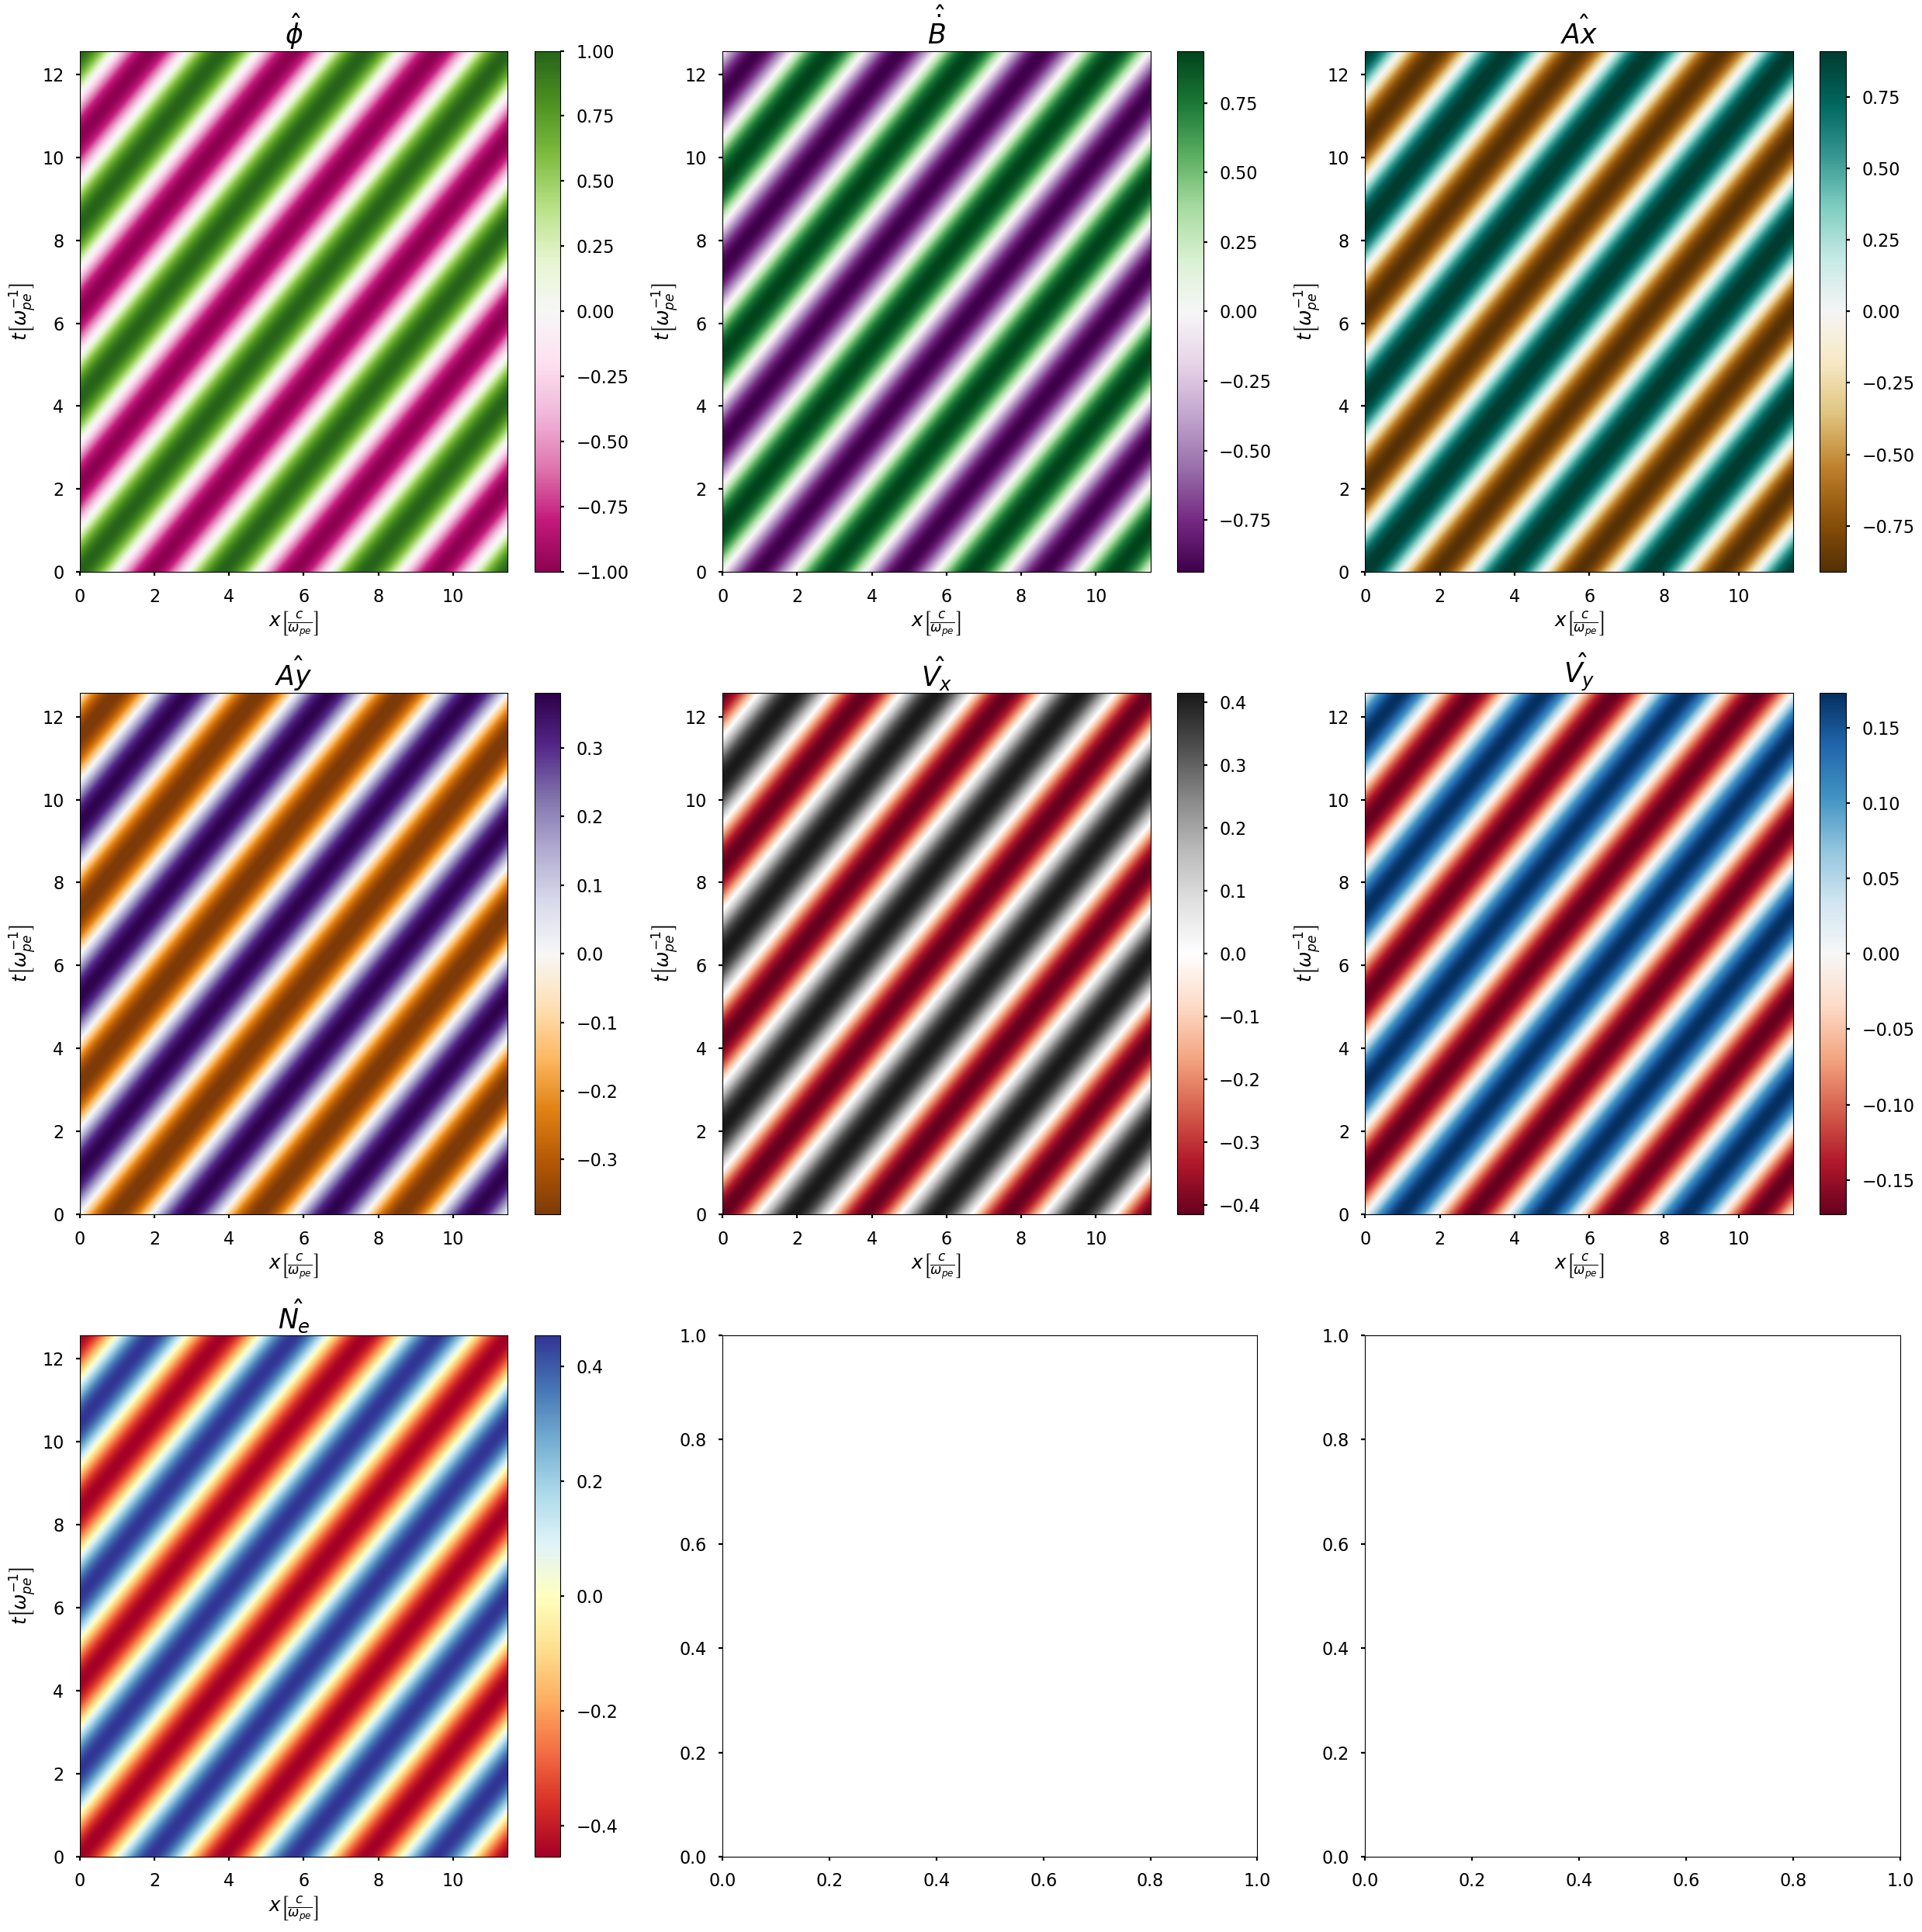

In [45]:
Nt, Nx = 2000, 2000
ground_truth_tensor = torch.tensor([phi_flat, Bdot_flat, Ax_flat, Ay_flat, Vx_flat, Vy_flat, N_flat], 
                                    device='cuda:0',)
ground_truth_list = [arr.cpu().numpy().reshape(Nt, Nx) for arr in ground_truth_tensor]

if torch.cuda.is_available():
    cpu_model = model.to('cuda:0')
    means = means.to('cuda:0')
    stds = stds.to('cuda:0')
    
    with torch.no_grad():
        cpu_model.eval()
        plot_reconstructed_quantities(device = 'cuda:0',
                                      model=cpu_model,
                                      extent=np.array([tmin, tmax, xmin, xmax]),
                                      means=means, #cpu
                                      stds=stds, #cpu
                                      quantities_GT=ground_truth_list,
                                      Nt=Nt,
                                      Nx=Nx,
                                      just_sm=False,
                                      figsize=(25, 25))



# plot_reconstructed_quantities(device = 'cpu',
#                                   model=model,
#                                   extent=np.array([tmin, tmax, xmin, xmax]),
#                                   means=means,
#                                   stds=stds,
#                                   quantities_GT=ground_truth_list,
#                                   Nt=Nt,
#                                   Nx=Nx,
#                                   just_sm=False,
#                                   figsize=(15, 10))

In [44]:
def plot_reconstructed_quantities(device, model, extent, means, stds, quantities_GT, Nt, Nx, just_sm=False, figsize=(10, 5)):
    
    
    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)
    
    XX, TT = np.meshgrid(X, T)
    
    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=False)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=False)
    # print("tt_tensor device:", TT_tensor.device)
    # print("xx_tensor device:", XX_tensor.device)
    
    means = means.to(device)
    stds = stds.to(device)
    
       
    if just_sm==True:
        print("Testing on the sample measurements (No Physics Loss)")
        with torch.no_grad():
            model.eval()
            predictions = model(TT_tensor, XX_tensor) #model predict phi and bdot (THE SM)
        phi_pred = tensor_to_np(predictions[:, 0:1]*means[:,0:1]+stds[:,0:1], reshape = True, dims = (Nt, Nx))
        Bdot_pred = tensor_to_np(predictions[:, 1:2]*means[:,1:2]+stds[:,1:2], reshape = True, dims = (Nt, Nx))
        Ax_pred = np.zeros_like(Bdot_pred)
        Ay_pred = np.zeros_like(Bdot_pred)
        Vx_pred = np.zeros_like(Bdot_pred)
        Vy_pred = np.zeros_like(Bdot_pred)
        N_pred = np.zeros_like(Bdot_pred)
            
        
    else:
        with torch.no_grad():
            model.eval()
            # print("model device:", model.device)
            
            #undo normalization
            if means is not None and stds is not None:
                # print('means_device:', means.device)
                # print('stds_device:', stds.device)
                preds = (model(TT_tensor, XX_tensor))*stds + means
                preds = preds.detach().cpu()
                
            else:
                preds = (model(TT_tensor, XX_tensor)) #model predictions
                # preds_cpu = preds.cpu()
                # print("preds device:", preds_cpu.shape)
    
        phi_pred = tensor_to_np(preds[:,0], reshape=True, dims=(Nt,Nx))
        Bdot_pred = tensor_to_np(preds[:,1], reshape=True, dims=(Nt,Nx))
        Ax_pred = tensor_to_np(preds[:,2], reshape=True, dims=(Nt,Nx))
        Ay_pred = tensor_to_np(preds[:,3], reshape=True, dims=(Nt,Nx))
        Vx_pred = tensor_to_np(preds[:,4], reshape=True, dims=(Nt,Nx))
        Vy_pred = tensor_to_np(preds[:,5], reshape=True, dims=(Nt,Nx))
        N_pred = tensor_to_np(preds[:,6], reshape=True, dims=(Nt,Nx))
        
        predictions = [phi_pred, Bdot_pred, Ax_pred, Ay_pred, Vx_pred, Vy_pred, N_pred]
    
    
    # print("phi_pred shape:", phi_pred.shape)
    
    # Plotting the reconstructed quantities
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=figsize)
    predictions = [phi_pred, Bdot_pred, Ax_pred, Ay_pred, Vx_pred, Vy_pred, N_pred]
    ground_truths = quantities_GT
    titles = [r'$\hat{\phi}$', 
              r'$\hat{\dot{B}}$', 
              r'$\hat{Ax}$',
              r'$\hat{Ay}$',
              r'$\hat{V_x}$', 
              r'$\hat{V_y}$', 
              r'$\hat{N_e}$']
    
    colors = ['PiYG', 'PRGn', 'BrBG',
              'PuOr', 'RdGy', 'RdBu',
              'RdYlBu', 'RdYlGn', 'bwr']
    
    # plt.suptitle("Reconstructed Quantities from PINN", fontsize=40)
    
    for ax, quantity, title, ground_truth, color in zip(axes.flatten(), predictions, titles, ground_truths, colors):
        im = ax.imshow(quantity, aspect='auto', extent=[extent[2], extent[3], extent[0], extent[1]], origin='lower', vmin = -np.max(np.abs(ground_truth)), vmax = np.max(np.abs(ground_truth)), cmap=color)
        ax.set_title(title, fontsize=25)
        ax.set_xlabel(r'$x \left[\frac{c}{\omega_{pe}}\right]$')
        ax.set_ylabel(r'$t \left[\omega_{pe}^{-1}\right]$')
        fig.colorbar(im, ax=ax)
    # plt.figure(figsize=figsize)
    plt.tight_layout()
    # plt.suptitle("Reconstructed Quantities from PINN", fontsize=30)
    plt.show()
    # plt.savefig("XWave_reconstructed_quantities")
    
def plot_reconstructed_quantities_residuals(device, model, extent, Nt, Nx, means, stds):
    
    """Plot the residuals of the reconstructed quantities.
    -Warning: Might run out of memeory for large Nt and Nx."""
    
    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)
    
    dt = (extent[1] - extent[0])/Nt
    dx = (extent[3] - extent[2])/Nx
    
    XX, TT = np.meshgrid(X, T)
    
    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), dtype=torch.float32, device=device, requires_grad=True)
    
    residuals = pde_residuals(model, TT_tensor, XX_tensor, np_to_tensor(np.real(B0_flat)[0]), means, stds)
    
    gauge_res = tensor_to_np(residuals[:, 0:1], reshape=True, dims=(Nt, Nx))
    gauss_res = tensor_to_np(residuals[:, 1:2], reshape=True, dims=(Nt, Nx))
    ampere_x_res = tensor_to_np(residuals[:, 2:3], reshape=True, dims=(Nt, Nx))
    ampere_y_res = tensor_to_np(residuals[:, 3:4], reshape = True, dims = (Nt, Nx))
    bdot_curlA_res = tensor_to_np(residuals[:, 4:5], reshape = True, dims = (Nt, Nx))
    momentum_x_res = tensor_to_np(residuals[:, 5:6], reshape = True, dims = (Nt, Nx))
    momentum_y_res = tensor_to_np(residuals[:, 6:7], reshape = True, dims = (Nt, Nx))
    continuity_res = tensor_to_np(residuals[:, 7:8], reshape=True, dims=(Nt, Nx))

    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 20))
    titles = [r'$|\partial_x A_x + \partial_t \phi|$', 
              r'$|\partial_{xx}^2 \phi + \partial_{xt}^2 A_x - N_e|$', 
              r'$|\partial_{tt}^2 A_x + \partial_{xt}^2 \phi + v_x|$',
              r'$|\partial_{tt}^2 A_y - \partial_{xx}^2 A_y + v_y|$', 
              r'$|\dot{B} - \partial^2_{xt} A_y|$', 
              r'$|\partial_t v_x - \partial_x \phi - \partial_t A_x + v_y B_0|$',
              r'$|\partial_t v_y - \partial_t A_y - v_x B_0|$',
              r'$|\partial_t n_e + \partial_x v_x|$']
    
    quantities = [gauge_res, gauss_res, ampere_x_res, ampere_y_res, momentum_x_res, 
                 momentum_y_res, bdot_curlA_res, momentum_x_res, 
                 momentum_y_res, continuity_res]
    
    for ax, quantity, title in zip(axes.flatten(), quantities, titles):
        im = ax.imshow(quantity, aspect='auto', extent=[extent[2], extent[3], extent[0], extent[1]], origin='lower', cmap='Reds')
        ax.set_title(title)
        ax.set_xlabel(r'$x \left[\frac{c}{\omega_{pe}}\right]$')
        ax.set_ylabel(r'$t \left[\omega_{pe}^{-1}\right]$')
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()
    # plt.savefig("reconstructed_quantities_residuals")
    print("Reconstruction Residuals plotted successfully.")
    
    return 

def plot_reconstructed_quantities_errors(device, model, extent, Nt, Nx, ground_truths):
    
    #ground_truts = [Ex_GT, Ey_GT, Bz_GT, Vx_GT, Vy_GT, N_GT, P_x_GT, phi_GT, Bdot_GT]
    
    T = np.linspace(extent[0], extent[1], Nt)
    X = np.linspace(extent[2], extent[3], Nx)
    
    XX,TT = np.meshgrid(X, T)
    
    TT_tensor = torch.tensor(TT.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)
    XX_tensor = torch.tensor(XX.flatten().reshape(-1,1), requires_grad=False, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        predictions = (model(TT_tensor, XX_tensor))
    
    phi_pred = tensor_to_np(predictions[:, 0:1], reshape=True, dims=(Nt, Nx))
    Bdot_pred = tensor_to_np(predictions[:, 1:2], reshape=True, dims=(Nt, Nx))
    Ax_pred = tensor_to_np(predictions[:,2:3], reshape = True, dims = (Nt, Nx))
    Ay_pred = tensor_to_np(predictions[:,3:4], reshape = True, dims = (Nt, Nx))
    Vx_pred = tensor_to_np(predictions[:, 4:5], reshape=True, dims=(Nt, Nx))
    Vy_pred = tensor_to_np(predictions[:, 5:6], reshape=True, dims=(Nt, Nx))
    N_pred = tensor_to_np(predictions[:, 6:7], reshape=True, dims=(Nt, Nx))
    
    
    
    #Plotting th relative errors of the reconstructed quantities
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(25, 25))
    
    rel_errors = []
    quantities_str = [r'$\phi$', 
                     r'$\dot{B}$',
                     r'$A_x', r'$A_y$', 
                     r'$v_x$', r'$v_y$', 
                     r'$n_e$']
    
    for pred, gt, quant_str in zip([phi_pred, Bdot_pred, Ax_pred, Ay_pred, Vx_pred, Vy_pred, N_pred], ground_truths, quantities_str):
        gt = gt.reshape(Nt, Nx)
        # print(gt.shape)
        rel_error = pred - gt
        # print(f"Relative error {quant_str}: ", rel_error)
        rel_errors.append(rel_error)
    
    error_titles = [r'$|\phi - \hat{\phi}|$',
                    r'$|\dot{B} - \hat{\dot{B}}|$',
                    r'$|A_x - \hat{A_x}|$', 
                    r'$|A_y - \hat{A_y}|$',
                    r'$|v_x - \hat{v_x}|$',
                    r'$|v_y - \hat{v_y}|$',
                    r'$|n_e - \hat{n_e}|$']
    
    for ax, rel_error, title in zip(axes.flatten(), rel_errors, error_titles):
        im = ax.imshow(rel_error, aspect='auto', extent=[extent[2], extent[3], extent[0], extent[1]], origin='lower', cmap='bwr')
        ax.set_title(title, fontsize=25)
        ax.set_xlabel(r'$x \left[\frac{c}{\omega_{pe}}\right]$')
        ax.set_ylabel(r'$t \left[\omega_{pe}^{-1}\right]$')
        fig.colorbar(im, ax=ax)
    
    
    plt.tight_layout()
    # plt.suptitle("Relative Errors of Reconstructed Quantities", fontsize=30)
    plt.show()
    # plt.savefig("reconstructed_quantities_errors")
    print("Relative errors plotted successfully.")
    
    return 

In [ ]:
plot_reconstructed_quantities_errors(device = 'cuda:0',
                                  model=model,
                                  extent=model_params['extent'],
                                  Nt=100,
                                  Nx=100,
                                  ground_truths=ground_truth)

# plot_reconstructed_quantities_residuals(device = 'cuda:0',
#                                   model=model,
#                                   extent=model_params['extent'],
#                                   Nt=100,
#                                   Nx=100,
#                                   means=means_tensor,
#                                   stds=stds_tensor)

RuntimeError: shape '[100, 100]' is invalid for input of size 0

In [ ]:
import numpy as np

In [ ]:
def xwave_dispersion(omega, omega_ce):
    
    k = np.sqrt(omega**2 - (omega**2 - 1) / (omega**2 - 1 - omega_ce**2))
    
    return k

In [ ]:
# omega0 = 2.5
# omega_ce = 0.01

k0 = xwave_dispersion(omega0, omega_ce)

In [ ]:
print("k0: ", k0)

k0:  2.2912836908637337


In [ ]:
phi0 = 1.0

X = np.linspace(0.0, 2*np.pi, 100)
T = np.linspace(0.0, 2*np.pi, 200)
XX, TT = np.meshgrid(X, T)

phi = phi0 * np.exp(1j * (k0*XX - omega0*TT))
print(phi.shape)

(200, 100)


In [ ]:
N = (omega0**2 - k0**2) * phi

In [ ]:
from PINN_XWave_DDP import derivative_x, derivative_t, derivative_xx, derivative_tt

dx = X[1] - X[0]
dt = T[1] - T[0]

phi_xx = derivative_xx(phi, dx)
phi_tt = derivative_tt(phi, dt)

In [ ]:
check_this = phi_xx - phi_tt - N

In [ ]:
import matplotlib.pyplot as plt

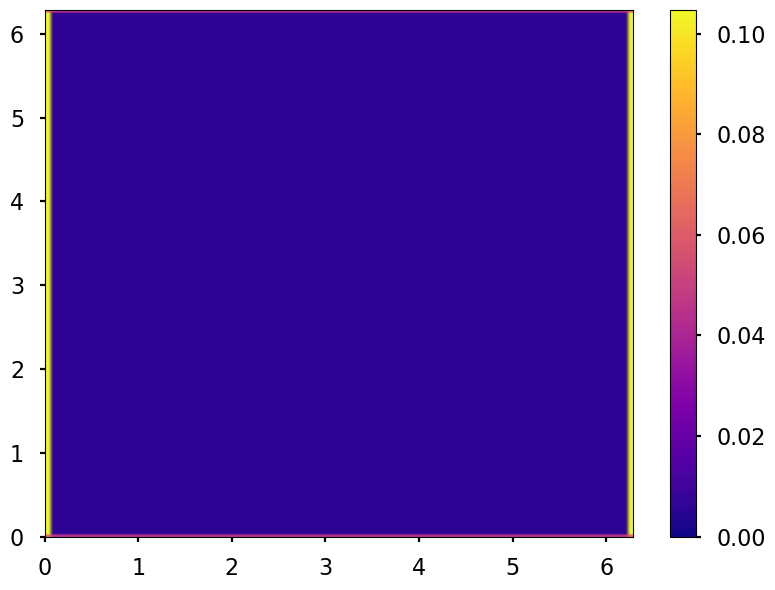

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(np.abs(check_this), aspect='auto', origin='lower', extent=[X[0], X[-1], T[0], T[-1]], vmin=0., vmax=np.max(np.abs(check_this)), cmap='plasma')
plt.colorbar()
plt.tight_layout()

In [ ]:
import numpy as np, torch
device = next(model.parameters()).device

# 1A: quick dtype and NaN checks
print("phi_sparse dtype / any imag / any NaN:",
      getattr(phi_sparse_np,'dtype',None),
      np.any(np.imag(phi_sparse_np) != 0) if np.iscomplexobj(phi_sparse_np) else False,
      np.any(np.isnan(phi_sparse_np)))
print("phi_flat (dense) dtype / any NaN:", getattr(phi_flat,'dtype',None), np.any(np.isnan(phi_flat)))
print("Bdot sparse/dense NaN?:", np.any(np.isnan(Bdot_sparse_np)), np.any(np.isnan(Bdot_flat)))

# 1B: ensure model in eval and no-grad
model.eval()

# 1C: print some raw y_train that was used for loss (first 8 rows)
try:
    print("y_train sample (first 8 rows):", y_train[:8].cpu().numpy())
except Exception as e:
    print("Couldn't access y_train directly:", e)

# 1D: Are means/stds present and their ranges?
if 'means' in globals() and 'stds' in globals():
    print("means shape/min/max:", np.asarray(means).shape, np.asarray(means).min(), np.asarray(means).max())
    print("stds shape/min/max:", np.asarray(stds).shape, np.asarray(stds).min(), np.asarray(stds).max())
else:
    print("means/stds not found in workspace.")


NameError: name 'phi_sparse_np' is not defined